### importing the modules & libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

### load data

In [2]:
taxi_data = pd.read_csv(r"C:\HHypothesis-analysis(python-project)\yellow_tripdata_2020-01.csv")

In [3]:
taxi_data.shape

(6405008, 18)

In [4]:
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [8]:
taxi_data.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [9]:
# converting pickup and dropoff to datetime 
taxi_data["tpep_pickup_datetime"] = pd.to_datetime(taxi_data["tpep_pickup_datetime"])
taxi_data["tpep_dropoff_datetime"] = pd.to_datetime(taxi_data["tpep_dropoff_datetime"])

In [10]:
taxi_data.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [11]:
# Calculating duration from the pickup and dropoff datetime in minutes

# subtracting the pickup time from dropoff time to get duration

taxi_data["trip_duration"] = taxi_data["tpep_dropoff_datetime"] - taxi_data["tpep_pickup_datetime"]
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:04:48
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:07:25
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:06:11
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:04:51
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:02:18


In [12]:
# convert trip_duration into munites.

taxi_data["trip_duration"] = taxi_data["trip_duration"].dt.total_seconds()/60
taxi_data["trip_duration"] = round(taxi_data["trip_duration"],2)
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.80
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.42
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.18
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.85
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.30


In [13]:
taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               float64       
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           float64       
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  trip_duration         

In [14]:
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.80
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.42
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.18
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.85
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.30


In [14]:
# There are so many columns in the dataset, but as per our problem statement, we only require some fields from the original data.
# Rest columns are nothing but the unwanted columns for this study. So we will simply remove those columns. 

# As the problem statement is revolving around the payment type, fare amount, and any other factor influencing the fare amount,
# we will filter the data to have only passenger count, trip distance, payment type, fare amount and duration of the trip.

taxi_data.drop(['VendorID','tpep_pickup_datetime','tpep_dropoff_datetime',
                'RatecodeID','store_and_fwd_flag','PULocationID','DOLocationID','extra',
                'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge'
                ,'total_amount','congestion_surcharge'],axis = 1,inplace = True)

In [15]:
taxi_data.head()

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
0,1.0,1.2,1.0,6.0,4.80
1,1.0,1.2,1.0,7.0,7.42
2,1.0,0.6,1.0,6.0,6.18
3,1.0,0.8,1.0,5.5,4.85
4,1.0,0.0,2.0,3.5,2.30


In [16]:
taxi_data.isnull().sum()

passenger_count    65441
trip_distance          0
payment_type       65441
fare_amount            0
trip_duration          0
dtype: int64

In [17]:
taxi_data.shape

(6405008, 5)

In [18]:
print(f"maissing value :{round(65441/taxi_data.shape[0]*100,2)}%")

maissing value :1.02%


In [19]:
# as the data has only 1% of data missing, we can simply drop the records with missing values
taxi_data.dropna(inplace = True)

In [20]:
taxi_data.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
trip_duration      0
dtype: int64

In [21]:
taxi_data.dtypes

passenger_count    float64
trip_distance      float64
payment_type       float64
fare_amount        float64
trip_duration      float64
dtype: object

In [22]:
# changing the passenger count and payment type data type to integer as they are present in float
taxi_data["passenger_count"] = taxi_data["passenger_count"].astype("int64")
taxi_data["payment_type"] = taxi_data["payment_type"].astype("int64")

In [23]:
taxi_data.dtypes

passenger_count      int64
trip_distance      float64
payment_type         int64
fare_amount        float64
trip_duration      float64
dtype: object

In [24]:
# check for the duplicate rows 
taxi_data[taxi_data.duplicated()]

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
2056,1,0.00,2,7.0,0.00
2441,1,0.00,1,52.0,0.20
2446,2,1.70,1,9.5,13.07
2465,1,0.40,1,4.0,3.08
3344,1,1.20,1,6.0,5.35
...,...,...,...,...,...
6339558,1,1.63,2,8.0,8.80
6339559,1,1.81,1,8.5,8.02
6339560,1,0.98,2,6.5,6.90
6339562,1,2.10,1,11.0,14.23


In [25]:
# removing duplicate rows as they will not contribute in analysis 
taxi_data.drop_duplicates(inplace = True)

In [26]:
taxi_data.shape

(3007861, 5)

In [27]:
taxi_data["passenger_count"].value_counts()

passenger_count
1    1750518
2     572547
3     199602
5     189305
6     118124
4     108422
0      69280
7         28
9         18
8         17
Name: count, dtype: int64

In [28]:
# passenger count distribution
taxi_data["passenger_count"].value_counts(normalize = True)*100

passenger_count
1    58.198102
2    19.035022
3     6.636011
5     6.293675
6     3.927176
4     3.604621
0     2.303298
7     0.000931
9     0.000598
8     0.000565
Name: proportion, dtype: float64

In [29]:
# payment type distribution
taxi_data["payment_type"].value_counts(normalize = True)*100

payment_type
1    67.826705
2    30.757306
3     0.872148
4     0.543808
5     0.000033
Name: proportion, dtype: float64

In [30]:
# We will focus solowly on payment types 'card' and 'cash,' denoted by 1 and 2 in the dataset.
# To ensure our analysis centers on these payment methods,
# we'll filter the data accordingly, excluding all other types.

# Moreover, examining the distribution of passenger counts reveals that trips with more than 5 passengers are rare. Additionally, 
# trips with 0 passengers are impossible, as we expect at least one passenger to pay the fare amount. 
# Therefore, we will filter the passenger count to include only values ranging from 1 to 5.


In [31]:
# filtering for payment type 1 and 2

taxi_data = taxi_data[taxi_data["payment_type"]<3]
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
0,1,1.20,1,6.0,4.80
1,1,1.20,1,7.0,7.42
2,1,0.60,1,6.0,6.18
3,1,0.80,1,5.5,4.85
4,1,0.00,2,3.5,2.30
...,...,...,...,...,...
6339555,3,2.09,1,10.0,14.80
6339561,1,4.11,1,17.5,21.50
6339563,1,2.13,1,13.0,19.00
6339564,1,2.55,1,12.5,16.28


In [32]:
# filtering for passenger count from 1 to 2
taxi_data[(taxi_data["passenger_count"] >0) & (taxi_data["passenger_count"] <6)]

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
0,1,1.20,1,6.0,4.80
1,1,1.20,1,7.0,7.42
2,1,0.60,1,6.0,6.18
3,1,0.80,1,5.5,4.85
4,1,0.00,2,3.5,2.30
...,...,...,...,...,...
6339555,3,2.09,1,10.0,14.80
6339561,1,4.11,1,17.5,21.50
6339563,1,2.13,1,13.0,19.00
6339564,1,2.55,1,12.5,16.28


In [33]:
taxi_data["passenger_count"].value_counts()

passenger_count
1    1720358
2     565797
3     197946
5     188786
6     117875
4     107396
0      67049
7         28
9         18
8         17
Name: count, dtype: int64

In [34]:
# replacing the payment type encoded value 1 and 2 to Card and Cash

taxi_data["payment_type"].replace([1,2],['Card','Cash'],inplace = True)

In [35]:
taxi_data.head()

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
0,1,1.2,Card,6.0,4.80
1,1,1.2,Card,7.0,7.42
2,1,0.6,Card,6.0,6.18
3,1,0.8,Card,5.5,4.85
4,1,0.0,Cash,3.5,2.30


In [36]:
# descriptive statistics for data

taxi_data.describe()

,passenger_count,trip_distance,fare_amount,trip_duration
count,2.965270e+06,2.965270e+06,2.965270e+06,2.965270e+06
mean,1.863927e+00,4.462182e+00,1.756830e+01,2.384796e+01
std,1.439961e+00,4.857628e+00,1.493143e+01,9.191510e+01
min,0.000000e+00,-2.218000e+01,-5.000000e+02,-2.770370e+03
25%,1.000000e+00,1.470000e+00,8.500000e+00,9.680000e+00
50%,1.000000e+00,2.670000e+00,1.300000e+01,1.550000e+01
75%,2.000000e+00,5.330000e+00,2.050000e+01,2.312000e+01
max,9.000000e+00,2.628800e+02,4.265000e+03,8.525120e+03


In [37]:
# Upon reviewing the provided statistics, it's evident that the minimum values for trip distance, fare amount, and duration are negative, 
# which is unrealistic and invalid for further analysis. Consequently, we will eliminate these negative values from the dataset.

# Furthermore, observing the maximum and 50th percentile values, it's possible that the data contains significant outliers,
# particularly high values. These outliers need to be addressed and removed to ensure the integrity of the analysis.

In [38]:
# filtering the records for only positive values

taxi_data = taxi_data[taxi_data["fare_amount"] > 0]
taxi_data = taxi_data[taxi_data["trip_duration"] > 0]
taxi_data = taxi_data[taxi_data["trip_distance"] > 0]


In [39]:
# descriptive statistics for data
taxi_data.describe()

,passenger_count,trip_distance,fare_amount,trip_duration
count,2.932570e+06,2.932570e+06,2.932570e+06,2.932570e+06
mean,1.870109e+00,4.507063e+00,1.743256e+01,2.387730e+01
std,1.443469e+00,4.859867e+00,1.434906e+01,9.202326e+01
min,0.000000e+00,1.000000e-02,1.000000e-02,2.000000e-02
25%,1.000000e+00,1.500000e+00,8.500000e+00,9.750000e+00
50%,1.000000e+00,2.700000e+00,1.300000e+01,1.552000e+01
75%,2.000000e+00,5.400000e+00,2.050000e+01,2.308000e+01
max,9.000000e+00,2.628800e+02,4.265000e+03,8.525120e+03


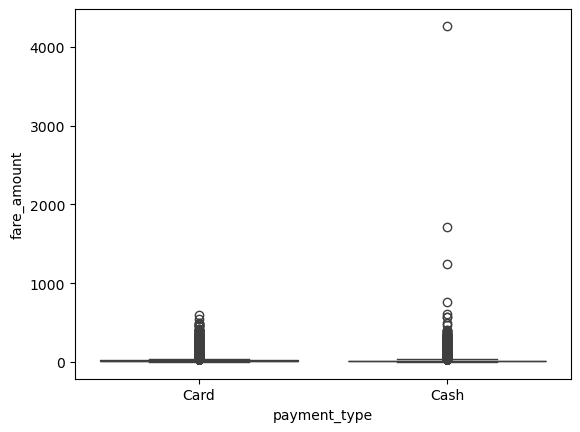

In [40]:
# check for the outliers
sns.boxplot(data = taxi_data,x = "payment_type",y = "fare_amount")
plt.show()

In [41]:
# removing outliers using interquartile range for the numerical variables

for col in ["trip_distance","fare_amount","trip_duration"]:
    q1 = taxi_data[col].quantile(0.25)
    q3 = taxi_data[col].quantile(0.75)
    IQR = q3 - q1

    # Define lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    # Filter out outliers
    taxi_data = taxi_data[(taxi_data[col] <= upper_bound) & (taxi_data[col] >= lower_bound)]

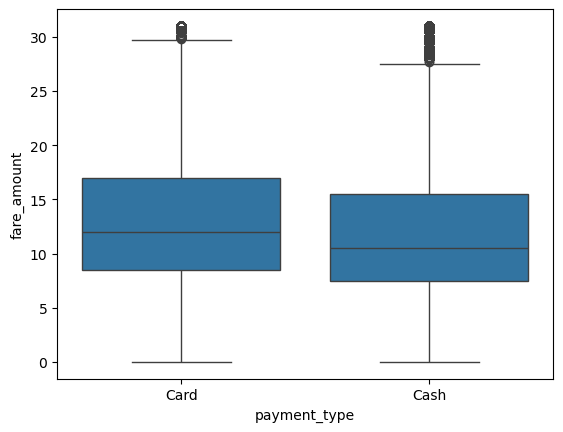

In [43]:
# check for the outliers
sns.boxplot(data = taxi_data,x = "payment_type",y = "fare_amount")
plt.show()

In [45]:
# We're interested on exploring the relationship between payment type and passenger behavior concerning trip distance and fare amount.
# Are there variations in the distribution of payment types concerning different fare amounts or trip distances?

# To investigate this, we'll plot histograms to visualize the distribution of passenger counts paying with either card or cash. 
# This will also provide stakeholders with insight into fare amount ranges associated with different payment methods.

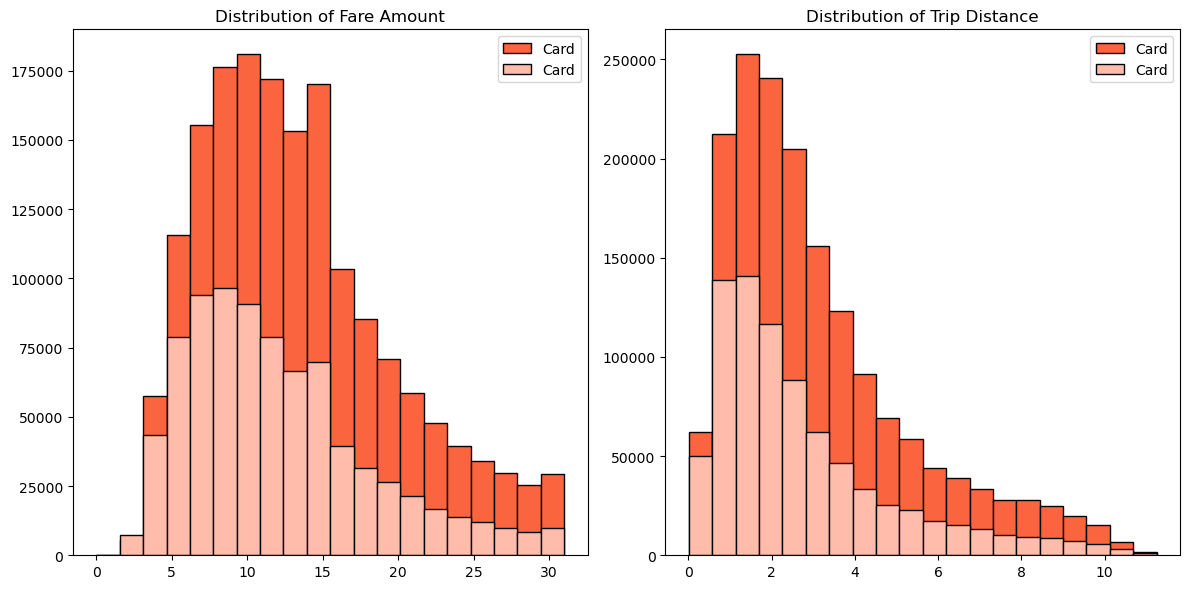

In [49]:
fig,ax = plt.subplots(1,2,figsize = (12,6))

ax[0].hist(taxi_data[taxi_data['payment_type']=='Card']['fare_amount'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Card')
ax[0].hist(taxi_data[taxi_data['payment_type']=='Cash']['fare_amount'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Card')
ax[0].set_title('Distribution of Fare Amount')
ax[0].legend()

ax[1].hist(taxi_data[taxi_data['payment_type']=='Card']['trip_distance'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Card')
ax[1].hist(taxi_data[taxi_data['payment_type']=='Cash']['trip_distance'], histtype='barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Card')
ax[1].set_title('Distribution of Trip Distance')
ax[1].legend()
plt.tight_layout()
plt.show()

In [53]:
# calculating the mean and standard deviation group by on payment type 
taxi_data.groupby("payment_type",as_index = False).agg({"fare_amount" : ["std","mean"],"trip_distance" : ["std","mean"]}) 

payment_type fare_amount           trip_distance          
                       std      mean           std      mean
0         Card    6.314951  13.39155      2.235633  3.124939
1         Cash    6.081029  12.03559      2.160120  2.730846

In [55]:
# Now, in order to examine the passenger's preference regarding their choice of payment method, we will assess the proportion of the two payment types.
# To provide a visual representation, we have opted to utilize a pie chart. 
# This graphical depiction will offer a clear and intuitive understanding of the distribution between the two payment methods chosen by passengers.


In [59]:
taxi_data['payment_type'].value_counts().index

Index(['Card', 'Cash'], dtype='object', name='payment_type')

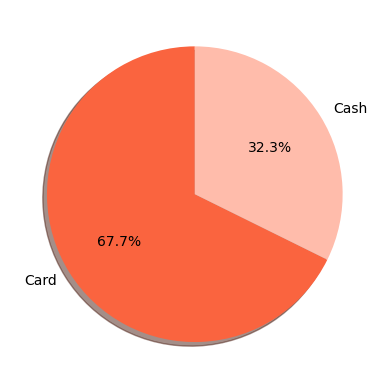

In [60]:
plt.pie(taxi_data["payment_type"].value_counts(normalize = True),labels = taxi_data['payment_type'].value_counts().index,
        startangle = 90,shadow = True, autopct = '%1.1f%%', colors = ['#FA643F','#FFBCAB'])
plt.show()

In [ ]:
# Subsequently, we aim to conduct an analysis of the payment types in relation to the passenger count. 
# Our objective is to investigate if there are any changes in preference contingent upon the number of passengers traveling in the cab. 

# To facilitate this examination, we have employed a visualization technique known as a stacked bar plot. 
# This method is particularly advantageous for comparing the percentage distribution of each passenger count based on the payment method selected. 
#Through this graphical representation, we can gain insights into potential variations in payment preferences across different passenger counts.

In [74]:
# calculating the total passenger count distribution based on the different payment type

passenger_count = taxi_data.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count

passenger_count
payment_type passenger_count                 
Card         0                          40870
             1                         942650
             2                         334413
             3                         124088
             4                          64502
             5                         125743
             6                          78670
             7                              2
             8                              2
             9                              2
Cash         0                          18339
             1                         473150
             2                         158410
             3                          55299
             4                          33096
             5                          48288
             6                          29939
             7                              3

In [75]:
passenger_count.columns

Index(['passenger_count'], dtype='object')

In [77]:
# renaming the column passenger_count to count to reset the index

passenger_count.rename(columns = {"passenger_count":"count"},inplace = True)
passenger_count

count
payment_type passenger_count        
Card         0                 40870
             1                942650
             2                334413
             3                124088
             4                 64502
             5                125743
             6                 78670
             7                     2
             8                     2
             9                     2
Cash         0                 18339
             1                473150
             2                158410
             3                 55299
             4                 33096
             5                 48288
             6                 29939
             7                     3

In [80]:
passenger_count.reset_index(inplace = True)
passenger_count

,index,payment_type,passenger_count,count
0,0,Card,0,40870
1,1,Card,1,942650
2,2,Card,2,334413
3,3,Card,3,124088
4,4,Card,4,64502
5,5,Card,5,125743
6,6,Card,6,78670
7,7,Card,7,2
8,8,Card,8,2
9,9,Card,9,2


In [83]:
# calculating the percentage of the each passenger count

passenger_count["perc"] = round((passenger_count["count"]/passenger_count["count"].sum())*100,2)
passenger_count

,index,payment_type,passenger_count,count,perc
0,0,Card,0,40870,1.62
1,1,Card,1,942650,37.30
2,2,Card,2,334413,13.23
3,3,Card,3,124088,4.91
4,4,Card,4,64502,2.55
5,5,Card,5,125743,4.98
6,6,Card,6,78670,3.11
7,7,Card,7,2,0.00
8,8,Card,8,2,0.00
9,9,Card,9,2,0.00


In [84]:
# creating a new empty dataframe to store the distribution of each payment type (useful for the visualization)
df = pd.DataFrame(columns = ['payment_type',1,2,3,4,5])
df

,payment_type,1,2,3,4,5


In [85]:
df['payment_type'] = ['card','cash']
df

,payment_type,1,2,3,4,5
0,card,NaN,NaN,NaN,NaN,NaN
1,cash,NaN,NaN,NaN,NaN,NaN


In [90]:
df.iloc[0,1:] = passenger_count.iloc[1:6,-1].values
df.iloc[1,1:] = passenger_count.iloc[11:16,-1].values
df

,payment_type,1,2,3,4,5
0,card,37.3,13.23,4.91,2.55,4.98
1,cash,18.72,6.27,2.19,1.31,1.91


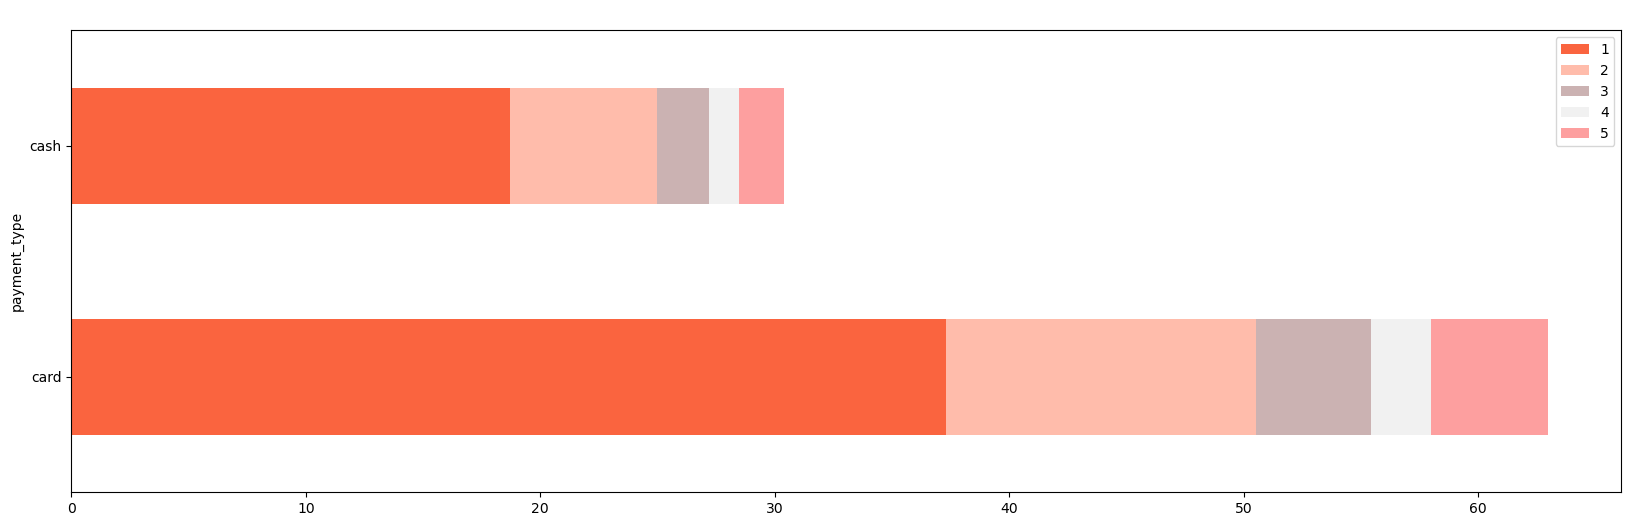

In [93]:
fig,ax = plt.subplots(figsize = (20,6))
df.plot(x = "payment_type",kind='barh', stacked=True, title=' ', ax=ax, color = ['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F'] )
plt.show()


### Hypothesis Testing

In [94]:
# In order to select the most suitable test for our scenario, 
# our initial step involves evaluating whether the distribution of fare amounts adheres to a normal distribution.
# While the histogram depicted above suggests otherwise, we will further confirm this by generating a QQ plot.

# Quantile-quantile (QQ) plots can be used to assess whether the fare amount distributions for each payment type are approximately normally distributed. 
# If the data points closely align with the diagonal line in the plot, it suggests that the data follows a normal distribution.

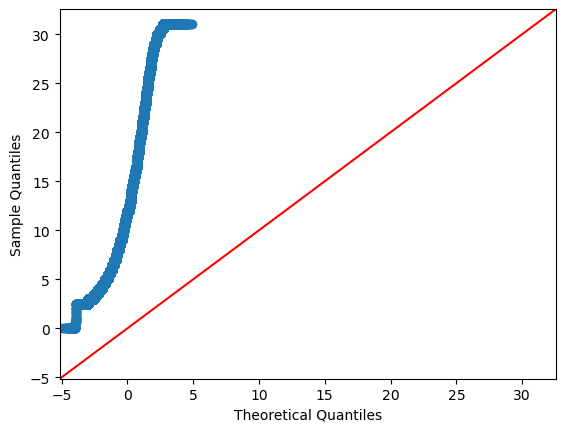

In [96]:
#create Q-Q plot with 45-degree line added to plot
fig = sm.qqplot(taxi_data['fare_amount'], line='45')
plt.show()

In [97]:
# The data values clearly do not follow the red 45-degree line, which is an indication that they do not follow a normal distribution. 
# So, z distribution will not be good for this. That's why we will use T test.

# Given that the T-test can be applied to both small and large samples and does not require the population standard deviation, 
# it is a more universally applicable approach for hypothesis testing in many practical research scenarios, including analyses of taxi trip data.


# In the analysis of NYC Yellow Taxi Trip Records, where you're likely dealing with an unknown population standard deviation and
# potentially large datasets, the T-test offers a more appropriate and flexible method for comparing means
# between two groups (e.g., fare amounts by payment type). It provides a reliable way to infer about the population, 
# accommodating the uncertainty that comes with estimating population parameters from sample data.

###Null hypothesis**: There is no difference in average fare between customers who use credit cards and customers who use cash. 

###Alternative hypothesis**: There is a difference in average fare between customers who use credit cards and customers who use cash



In [98]:
taxi_data.head(5)

,passenger_count,trip_distance,payment_type,fare_amount,trip_duration
0,1,1.20,Card,6.0,4.80
1,1,1.20,Card,7.0,7.42
2,1,0.60,Card,6.0,6.18
3,1,0.80,Card,5.5,4.85
5,1,0.03,Cash,2.5,0.88


In [99]:
# sample 1

credit_card = taxi_data[taxi_data["payment_type"] == "Card"]["fare_amount"]
credit_card

0           6.0
1           7.0
2           6.0
3           5.5
9           8.0
           ... 
6339550    10.5
6339555    10.0
6339561    17.5
6339563    13.0
6339564    12.5
Name: fare_amount, Length: 1710942, dtype: float64

In [102]:
# sample 2
cash = taxi_data[taxi_data["payment_type"] == "Cash"]["fare_amount"]
cash

5           2.5
11          9.5
15          9.0
17         11.5
18         24.5
           ... 
6339497    30.0
6339503    27.5
6339517    10.5
6339527    12.5
6339529    26.0
Name: fare_amount, Length: 816524, dtype: float64

In [103]:
credit_card = taxi_data[taxi_data["payment_type"] == "Card"]["fare_amount"]
cash = taxi_data[taxi_data["payment_type"] == "Cash"]["fare_amount"]

# performing t test on both the different sample
t_stat,p_value = stats.ttest_ind(a = credit_card,b = cash,equal_var = False)

print(f"t-statistic : {t_stat} , P-Value: {p_value}")

t-statistic : 163.7181765024551 , P-Value: 0.0


In [104]:
# comparing the p value with the significance of 5% or 0.05
if p_value <= 0.05:
    print("\nReject the null hypothesis")
else:
    print("\nAccept the null hypothesis")


Reject the null hypothesis


In [105]:
# Since the p-value is significantly smaller than the significance level of 5%, we will reject the null hypothesis.

# we conclude that there is a statistically significant difference in the average fare amount between customers who use credit cards and 
# customers who use cash.

# The key business insight is that encouraging customers to pay with credit cards can generate more revenue for taxi cab drivers.